In [51]:
# import sys
# !{sys.executable} -m pip install -q Pillow

In [52]:
import os
import re
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.text import tokenizer_from_json

from L1.LibLv1 import create_efficientnet_models, load_model_from_weights_and_compile
from L2.LibLv2 import create_autoencoder
from LibLv3 import load_tokenizer, evaluate, plot_attention

In [53]:
# Define placeholder encoder/decoder classes for completeness
class CNN_Encoder(tf.keras.Model):
    def __init__(self, embedding_dim):
        super(CNN_Encoder, self).__init__()
        self.fc = tf.keras.layers.Dense(embedding_dim)

    def call(self, x):
        x = self.fc(x)
        x = tf.nn.relu(x)
        return x


class RNN_Decoder(tf.keras.Model):
    def __init__(self, embedding_dim, units, vocab_size):
        super(RNN_Decoder, self).__init__()
        self.units = units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(self.units,
                                       return_sequences=True,
                                       return_state=True,
                                       recurrent_initializer='glorot_uniform')
        self.fc1 = tf.keras.layers.Dense(self.units)
        self.fc2 = tf.keras.layers.Dense(vocab_size)
        self.attention = BahdanauAttention(self.units)

    def call(self, x, features, hidden):
        context_vector, attention_weights = self.attention(hidden, features)
        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        output, state = self.gru(x)
        x = self.fc1(output)
        x = tf.reshape(x, (-1, x.shape[2]))
        x = self.fc2(x)
        return x, state, attention_weights

    def reset_state(self, batch_size):
        return tf.zeros((batch_size, self.units))


class BahdanauAttention(tf.keras.Model):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, hidden_state, features):
        hidden_with_time_axis = tf.expand_dims(hidden_state, 1)
        score = tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis))
        attention_weights = tf.nn.softmax(self.V(score), axis=1)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights
    
class CaptioningModel(tf.keras.Model):
    def __init__(self, vocab_size):
        super(CaptioningModel, self).__init__()
        self.encoder = tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu")
        self.flatten = tf.keras.layers.Flatten()
        self.dense = tf.keras.layers.Dense(128, activation="relu")
        self.output_layer = tf.keras.layers.Dense(vocab_size)  # vocab_size = number of tokens

    def call(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        x = self.dense(x)
        return self.output_layer(x)

In [54]:
# Load the tokenizer from tokenizer.json
with open("tokenizer.json", "r", encoding="utf-8") as f:
    tokenizer_json = json.load(f)
tokenizer = tokenizer_from_json(tokenizer_json)

vocab_size = len(tokenizer.word_index) + 1  # Plus 1 for padding or unknown

In [55]:
def extract_efficientnet_version(weights_path):
    match = re.search(r'EfficientNet(B[0-7])', os.path.basename(weights_path))
    return match.group(1) if match else 'B0'

def run_pipeline(image_paths, classifier_weights, autoencoder_weights, caption_model_path,
                 class_names=['Not Photo', 'Photo'],
                 image_size=(224, 224),
                 gpu_device='/GPU:1'):
    """
    Pipeline: EfficientNet classification and autoencoder enhancement.
    """
    print("\n==========================")
    print("📦 Starting Inference Pipeline")
    print("==========================\n")

    if isinstance(image_paths, str):
        image_paths = [image_paths]

    version = extract_efficientnet_version(classifier_weights)

    with tf.device(gpu_device):
        # ------------------------ Load Models ------------------------
        print("🔍 [Model 1: Loading EfficientNet Classifier]")
        classifier = create_efficientnet_models(
            input_shape=(*image_size, 3),
            class_count=len(class_names),
            version=version,
            dropout_rate=0.3,
            fine_tune_at=-1
        )
        classifier = load_model_from_weights_and_compile(classifier, classifier_weights)
        if classifier is None:
            print("❌ Could not load classifier model.")
            return

        print("✨ [Model 2: Loading Autoencoder]")
        autoencoder = create_autoencoder((*image_size, 3))
        try:
            autoencoder.load_weights(autoencoder_weights)
            print("✅ Autoencoder weights loaded.\n")
        except Exception as e:
            print(f"❌ Failed to load autoencoder weights: {e}")
            return

        images_raw = []
        images_array = []
        predictions = []

        # ------------------------ STEP 1: Classification ------------------------
        print("\n============================")
        print("🔍 STEP 1: Classification with Model 1")
        print("============================\n")

        for path in image_paths:
            img_raw = image.load_img(path, target_size=image_size)
            img_array = image.img_to_array(img_raw)
            img_batch = np.expand_dims(preprocess_input(img_array.copy()), axis=0)

            pred = classifier.predict(img_batch)
            class_idx = np.argmax(pred[0])
            class_label = class_names[class_idx]
            confidence = pred[0][class_idx]

            predictions.append((class_label, confidence))
            images_raw.append(img_raw)
            images_array.append(img_array)

            print(f"🖼️ {os.path.basename(path)} → {class_label} ({confidence:.2%})")

        # Visual display of predictions
        for i, (img, (label, conf)) in enumerate(zip(images_raw, predictions)):
            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.title(f"[Model 1] {label} ({conf:.2%})")
            plt.axis("off")
            plt.show()

        # ------------------------ STEP 2: Enhancement ------------------------
        print("\n============================")
        print("✨ STEP 2: Enhancement with Model 2")
        print("============================\n")

        for i, (label, _) in enumerate(predictions):
            if label != 'Photo':
                print(f"🚫 Skipping {os.path.basename(image_paths[i])} (Not Photo)")
                continue

            img_array = images_array[i]
            img_batch = np.expand_dims(img_array / 255.0, axis=0)
            enhanced = autoencoder.predict(img_batch)[0]

            plt.figure(figsize=(10, 4))

            plt.subplot(1, 2, 1)
            plt.imshow(img_array.astype("uint8"))
            plt.title("Model 2 Input (Original)")
            plt.axis("off")

            plt.subplot(1, 2, 2)
            plt.imshow(enhanced)
            plt.title("Model 2 Output (Enhanced)")
            plt.axis("off")

            plt.tight_layout()
            plt.show()

            # ------------------------ STEP 3: Captioning with Attention ------------------------
            print("\n============================")
            print("📝 STEP 3: Captioning with Attention-Based Model")
            print("============================\n")

            # Load tokenizer from JSON
            tokenizer = load_tokenizer("tokenizer.json")

            # Config values (must match training setup)
            embedding_dim = 256
            units = 512
            vocab_size = len(tokenizer.word_index) + 1
            max_length = 50
            attention_features_shape = 64

            # Load encoder and decoder
            encoder = CNN_Encoder(embedding_dim)
            decoder = RNN_Decoder(embedding_dim, units, vocab_size)

            # Restore model checkpoint
            ckpt = tf.train.Checkpoint(encoder=encoder, decoder=decoder)
            try:
                ckpt.restore(tf.train.latest_checkpoint(caption_model_path)).expect_partial()
                print("✅ Captioning model restored.")
            except Exception as e:
                print(f"❌ Failed to load captioning model: {e}")
                return

            # Image feature extractor for InceptionV3
            image_model = tf.keras.applications.InceptionV3(include_top=False, weights='imagenet')
            new_input = image_model.input
            hidden_layer = image_model.layers[-1].output
            image_features_extract_model = tf.keras.Model(new_input, hidden_layer)

            # Run captioning for each image
            for i, (label, _) in enumerate(predictions):
                if label != 'Photo':
                    continue

                image_path = image_paths[i]
                caption, attention_plot = evaluate(
                    image_path=image_path,
                    encoder=encoder,
                    decoder=decoder,
                    tokenizer=tokenizer,
                    max_length=max_length,
                    attention_features_shape=attention_features_shape,
                    image_features_extract_model=image_features_extract_model
                )
                print('caption, attention_plot', caption, attention_plot)

                # Simple image + caption (no attention map)
                img = Image.open(image_path)
                plt.figure(figsize=(6, 6))
                plt.imshow(img)
                plt.title(f"📃 Caption: {caption}", fontsize=12)
                plt.axis("off")
                plt.tight_layout()
                plt.show()


                # print(f"\n📸 {os.path.basename(image_path)}")
                # print(f"📃 Caption: {caption}")
                # plot_attention(image_path, caption.split(), attention_plot)



In [56]:
image_list = [
    r"L1\\testResult\\WhatsApp Image 2025-04-08 à 10.02.35_57384aa3.jpg",
    r"L1\\testResult\\lorenzo.jpg",
    r"L1\\testResult\\WhatsApp Image 2025-04-08 à 10.02.35_b655e5ba.jpg"
]


📦 Starting Inference Pipeline

🔍 [Model 1: Loading EfficientNet Classifier]
Fine-tuning activé à partir de la couche -1.
Poids chargés avec succès depuis L1\\models\\EfficientNetB1_Bin_best_weights.h5
Modèle compilé avec succès.
✨ [Model 2: Loading Autoencoder]
✅ Autoencoder weights loaded.


🔍 STEP 1: Classification with Model 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
🖼️ WhatsApp Image 2025-04-08 à 10.02.35_57384aa3.jpg → Photo (99.96%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
🖼️ lorenzo.jpg → Not Photo (100.00%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
🖼️ WhatsApp Image 2025-04-08 à 10.02.35_b655e5ba.jpg → Not Photo (99.96%)


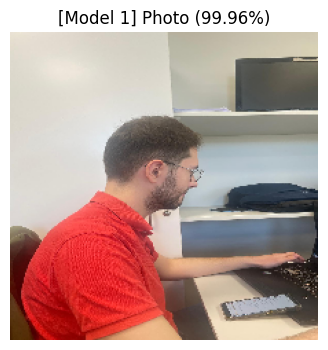

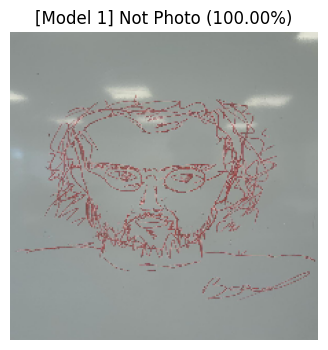

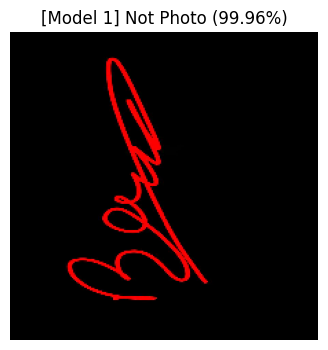


✨ STEP 2: Enhancement with Model 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


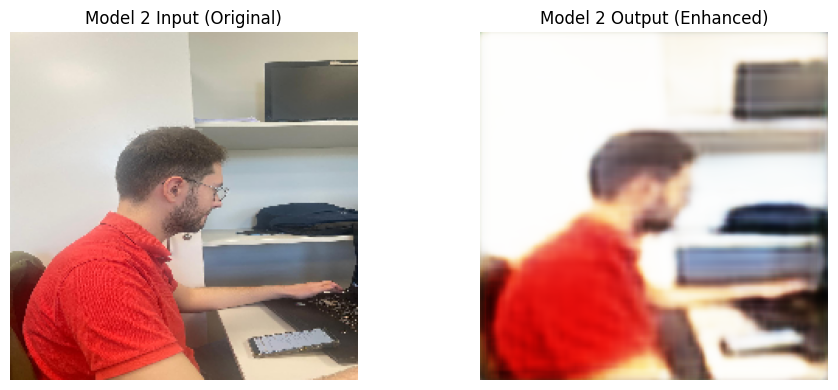


📝 STEP 3: Captioning with Attention-Based Model

✅ Captioning model restored.
caption, attention_plot saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers saucers [[0.00652171 0.00693507 0.00554434 ... 0.01107226 0.01322198 0.0326855 ]
 [0.00564356 0.00607827 0.0047569  ... 0.01059955 0.01488967 0.04201319]
 [0.0056255  0.00606258 0.00474537 ... 0.01059774 0.01498099 0.04253307]
 ...
 [0.00562608 0.00606346 0.00474603 ... 0.01059544 0.01497847 0.04254008]
 [0.00562608 0.00606346 0.00474603 ... 0.01059544 0.01497846 0.04254007]
 [0.00562608 0.00606346 0.00474603 ... 0.01059544 0.01497846 0.04254007]]


C:\Users\P3mas\AppData\Local\Temp\ipykernel_24664\2156596721.py:164: UserWarning: Glyph 128195 (\N{PAGE WITH CURL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


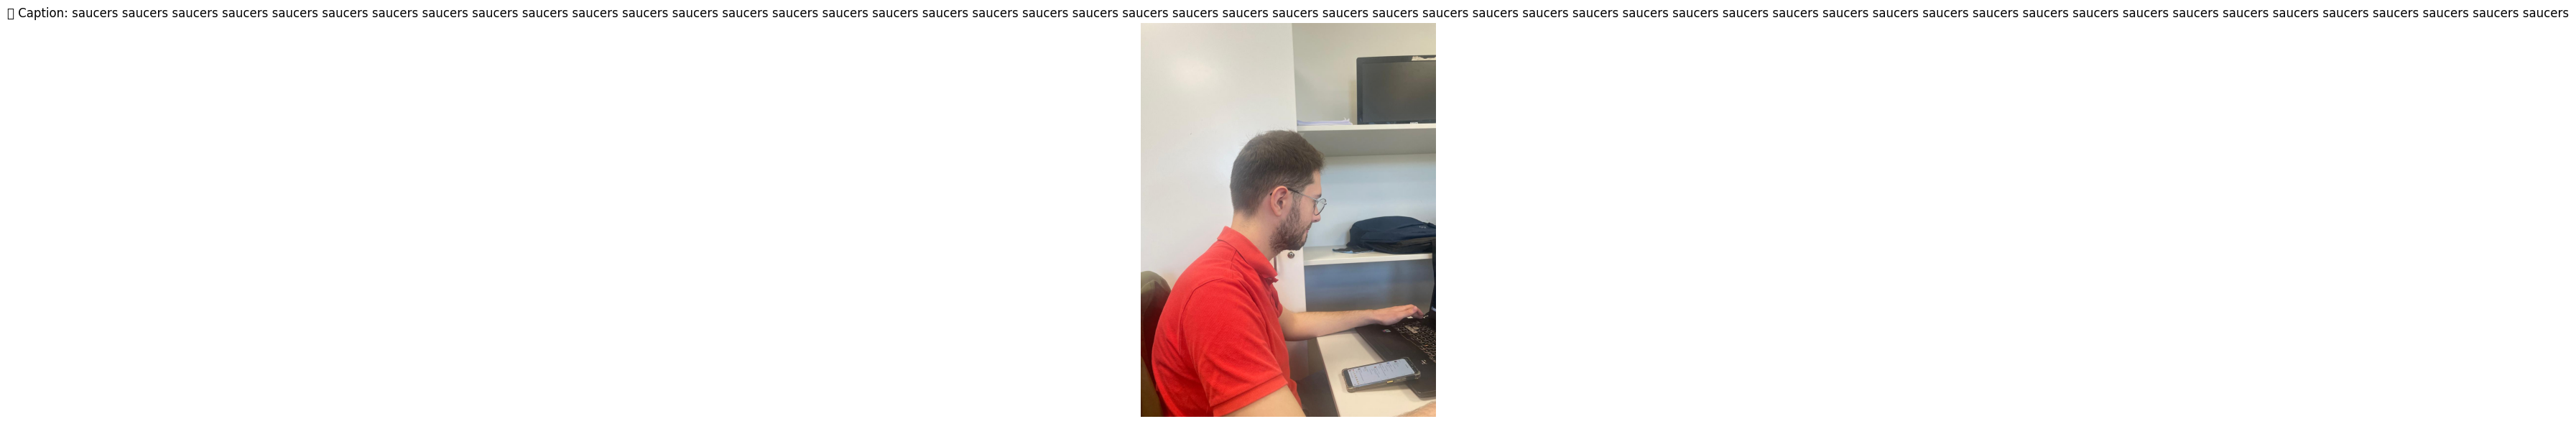

🚫 Skipping lorenzo.jpg (Not Photo)
🚫 Skipping WhatsApp Image 2025-04-08 à 10.02.35_b655e5ba.jpg (Not Photo)


In [57]:
run_pipeline(
    image_paths=image_list,
    classifier_weights=r"L1\\models\\EfficientNetB1_Bin_best_weights.h5",
    autoencoder_weights=r"L2\\autoencoder_weights.h5",
    caption_model_path=r"L3\\model_l3",
    class_names=["Not Photo", "Photo"],
    image_size=(224, 224),
    gpu_device='/GPU:1'  # or '/GPU:0' if needed
)